In [ ]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

import sys
from pathlib import Path
import importlib
from src.utils import DATA_ROOT, CHANNELS, BANDS, SUPPORT_RUNS, QUERY_RUNS

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils import set_seed, mean_sem_across_seeds, sample_target, sample_gain, sample_rotation
from src.models import Policy
from src.maml import adapt_k_steps
from src.control import rollout, trajectory_loss
from src.evaluate import param_deltas, final_losses_at_k, evaluate_adaptation
from src.train import train_maml_stationary, train_maml_rotation, train_maml_gain
from src.evaluate import trajectory_loss, evaluate_adaptation, evaluate_adaptation_drift, evaluate_adaptation_gain

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(0)


In [88]:
meta_iters=500
meta_batch=8
inner_steps=4
inner_lr=0.05
meta_lr=1e-3
T=30
dt=0.1

seeds = [0,1,2,3,4]
steps_list = (0, 1, 3, 5, 10)



In [56]:
# Plot parameters
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 5,
})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

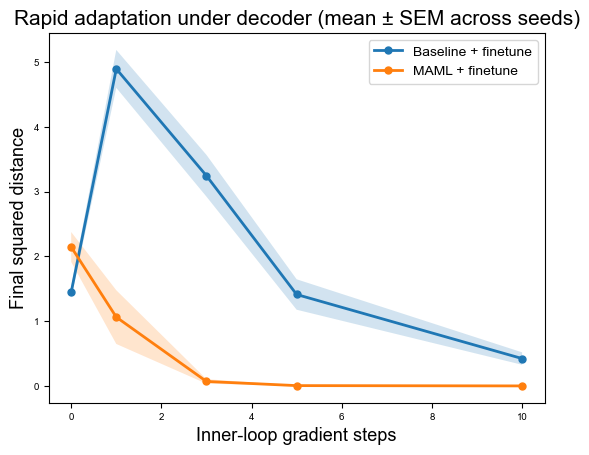

In [63]:

all_base_curves_stationary = []
all_maml_curves_stationary = []
all_meta_losses_stationary = []

for sd in seeds:
    meta_pol_stationary, base_pol_stationary, losses_stationary = train_maml_stationary(seed=sd, meta_iters=meta_iters,meta_batch=meta_batch,
        inner_steps=inner_steps, inner_lr=inner_lr, meta_lr=meta_lr, T=T, dt=dt)

    base_curve_stationary = evaluate_adaptation(base_pol_stationary,  n_tasks=200, steps_list=steps_list, inner_lr=inner_lr, T=T, dt=dt)
    maml_curve_stationary = evaluate_adaptation(meta_pol_stationary,  n_tasks=200, steps_list=steps_list, inner_lr=inner_lr, T=T, dt=dt)
    all_base_curves_stationary.append([base_curve_stationary[k] for k in steps_list])
    all_maml_curves_stationary.append([maml_curve_stationary[k] for k in steps_list])
    all_meta_losses_stationary.append(losses_stationary)

# Mean ± SEM across seeds (for each inner step)
base_mean_stationary, base_sem_stationary = mean_sem_across_seeds(all_base_curves_stationary)
maml_mean_stationary, maml_sem_stationary = mean_sem_across_seeds(all_maml_curves_stationary)

x = np.array(list(steps_list), dtype=np.float64)

plt.figure()
plt.plot(x, base_mean_stationary, marker="o", label="Baseline + finetune")
plt.fill_between(x, base_mean_stationary - base_sem_stationary, base_mean_stationary + base_sem_stationary, alpha=0.2)

plt.plot(x, maml_mean_stationary, marker="o", label="MAML + finetune")
plt.fill_between(x, maml_mean_stationary - maml_sem_stationary, maml_mean_stationary + maml_sem_stationary, alpha=0.2)

plt.xlabel("Inner-loop gradient steps")
plt.ylabel("Final squared distance")
plt.title("Rapid adaptation under decoder (mean ± SEM across seeds)")
plt.legend()
plt.show()

In [74]:
K_idx = list(steps_list).index(10)
print("Baseline mean ± SEM:", float(base_mean_stationary[K_idx]), float(base_sem_stationary[K_idx]))
print("MAML mean ± SEM:    ", float(maml_mean_stationary[K_idx]), float(maml_sem_stationary[K_idx]))

Baseline mean ± SEM: 0.422774733709309 0.09616738228169225
MAML mean ± SEM:     0.0001744310378923428 6.021355093520243e-05


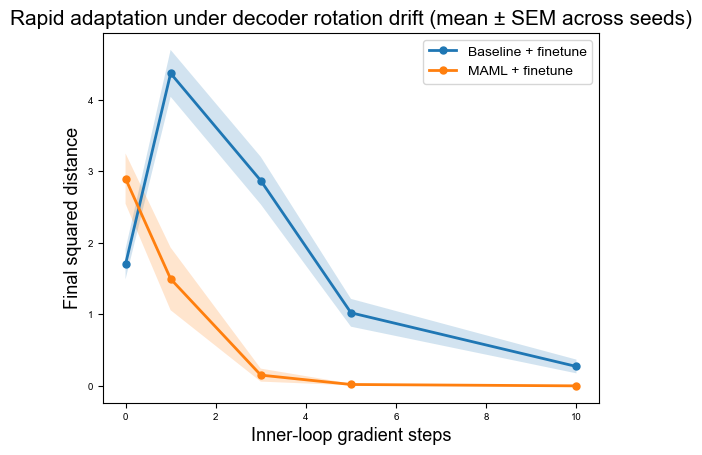

In [75]:
all_base_curves = []
all_maml_curves = []
all_meta_losses = []

for sd in seeds:
    meta_pol, base_pol, losses = train_maml_rotation(seed=sd, meta_iters=meta_iters,meta_batch=meta_batch,
        inner_steps=inner_steps, inner_lr=inner_lr, meta_lr=meta_lr, T=T, dt=dt, max_angle=0.4)

    base_curve = evaluate_adaptation_drift(base_pol, n_tasks=200, steps_list=steps_list, max_angle=0.4, inner_lr=inner_lr, T=T, dt=dt, gain=1.0)
    maml_curve = evaluate_adaptation_drift(meta_pol, n_tasks=200, steps_list=steps_list, max_angle=0.4, inner_lr=inner_lr, T=T, dt=dt, gain=1.0)

    all_base_curves.append([base_curve[k] for k in steps_list])
    all_maml_curves.append([maml_curve[k] for k in steps_list])
    all_meta_losses.append(losses)

# Mean ± SEM across seeds (for each inner step)
base_mean, base_sem = mean_sem_across_seeds(all_base_curves)
maml_mean, maml_sem = mean_sem_across_seeds(all_maml_curves)

x = np.array(list(steps_list), dtype=np.float64)

plt.figure()
plt.plot(x, base_mean, marker="o", label="Baseline + finetune")
plt.fill_between(x, base_mean - base_sem, base_mean + base_sem, alpha=0.2)

plt.plot(x, maml_mean, marker="o", label="MAML + finetune")
plt.fill_between(x, maml_mean - maml_sem, maml_mean + maml_sem, alpha=0.2)

plt.xlabel("Inner-loop gradient steps")
plt.ylabel("Final squared distance")
plt.title("Rapid adaptation under decoder rotation drift (mean ± SEM across seeds)")
plt.legend()
plt.show()


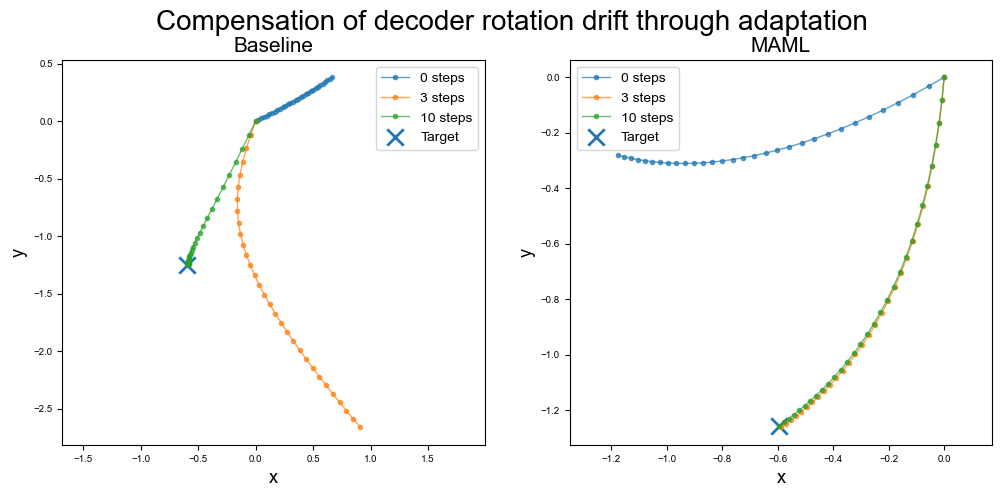

In [76]:
theta_test = torch.tensor(0.35, device=device)
target_xy_theta = sample_target(radius=1.5)

traj_maml_0_theta = rollout(meta_pol, target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()
traj_maml_3_theta = rollout(
    adapt_k_steps(meta_pol, target_xy_theta, k=3, theta=theta_test, inner_lr=inner_lr, T=T, dt=dt),
    target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()
traj_maml_10_theta = rollout(
    adapt_k_steps(meta_pol, target_xy_theta, k=10, theta=theta_test, inner_lr=inner_lr, T=T, dt=dt),
    target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()

traj_base_0_theta = rollout(base_pol, target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()
traj_base_3_theta = rollout(
    adapt_k_steps(base_pol, target_xy_theta, k=3, theta=theta_test, inner_lr=inner_lr, T=T, dt=dt),
    target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()
traj_base_10_theta = rollout(
    adapt_k_steps(base_pol, target_xy_theta, k=10, theta=theta_test, inner_lr=inner_lr, T=T, dt=dt),
    target_xy_theta, T=T, dt=dt, theta=theta_test).detach().cpu().numpy()
tgt_theta = target_xy_theta.detach().cpu().numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(traj_base_0_theta[:,0],  traj_base_0_theta[:,1],  marker="o", markersize=3, alpha=0.7, linewidth=1,  label="0 steps")
plt.plot(traj_base_3_theta[:,0], traj_base_3_theta[:,1], marker="o", markersize=3, alpha=0.7, linewidth=1, label="3 steps")
plt.plot(traj_base_10_theta[:,0], traj_base_10_theta[:,1], marker="o", markersize=3, alpha=0.7, linewidth=1, label="10 steps")
plt.scatter([tgt_theta[0]], [tgt_theta[1]], marker="x", s=140, label="Target")
plt.title('Baseline')
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.subplot(1,2,2)
plt.plot(traj_maml_0_theta[:,0],  traj_maml_0_theta[:,1],  marker="o", markersize=3, alpha=0.7, linewidth=1, label="0 steps")
plt.plot(traj_maml_3_theta[:,0], traj_maml_3_theta[:,1], marker="o", markersize=3, alpha=0.7, linewidth=1, label="3 steps")
plt.plot(traj_maml_10_theta[:,0], traj_maml_10_theta[:,1], marker="o", markersize=3, alpha=0.7, linewidth=1, label="10 steps")
plt.scatter([tgt_theta[0]], [tgt_theta[1]], marker="x", s=140, label="Target")
plt.title('MAML')
plt.suptitle('Compensation of decoder rotation drift through adaptation', fontsize=20)
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

In [77]:
K_idx = list(steps_list).index(10)

print("Baseline mean ± SEM:", float(base_mean[K_idx]), float(base_sem[K_idx]))
print("MAML mean ± SEM:    ", float(maml_mean[K_idx]), float(maml_sem[K_idx]))

Baseline mean ± SEM: 0.27227446098658215 0.0959535042246232
MAML mean ± SEM:     0.0012579186684112723 0.0008943749945571715


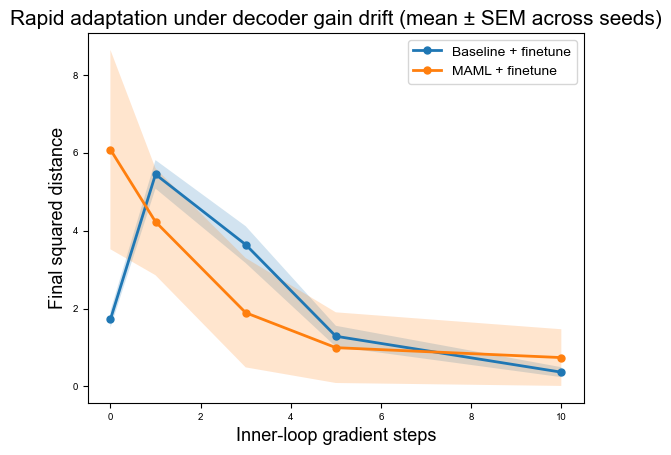

In [83]:
all_base_curves_gain = []
all_maml_curves_gain = []
all_meta_losses_gain = []

for sd in seeds:
    meta_pol_gain, base_pol_gain, losses_gain = train_maml_gain(seed=sd, meta_iters=meta_iters,meta_batch=meta_batch,
        inner_steps=inner_steps, inner_lr=inner_lr, meta_lr=meta_lr, T=T, dt=dt, min_gain=0.5, max_gain=1.5)

    base_curve_gain = evaluate_adaptation_gain(base_pol_gain,  steps_list=steps_list)
    maml_curve_gain = evaluate_adaptation_gain(meta_pol_gain,  steps_list=steps_list)
    all_base_curves_gain.append([base_curve_gain[k] for k in steps_list])
    all_maml_curves_gain.append([maml_curve_gain[k] for k in steps_list])
    all_meta_losses_gain.append(losses_gain)

# Mean ± SEM across seeds (for each inner step)
base_mean_gain, base_sem_gain = mean_sem_across_seeds(all_base_curves_gain)
maml_mean_gain, maml_sem_gain = mean_sem_across_seeds(all_maml_curves_gain)

x = np.array(list(steps_list), dtype=np.float64)

plt.figure()
plt.plot(x, base_mean_gain, marker="o", label="Baseline + finetune")
plt.fill_between(x, base_mean_gain - base_sem_gain, base_mean_gain + base_sem_gain, alpha=0.2)

plt.plot(x, maml_mean_gain, marker="o", label="MAML + finetune")
plt.fill_between(x, maml_mean_gain - maml_sem_gain, maml_mean_gain + maml_sem_gain, alpha=0.2)

plt.xlabel("Inner-loop gradient steps")
plt.ylabel("Final squared distance")
plt.title("Rapid adaptation under decoder gain drift (mean ± SEM across seeds)")
plt.legend()
plt.show()

In [84]:
K_idx = list(steps_list).index(10)

print("Baseline mean ± SEM:", float(base_mean_gain[K_idx]), float(base_sem_gain[K_idx]))
print("MAML mean ± SEM:    ", float(maml_mean_gain[K_idx]), float(maml_sem_gain[K_idx]))


Baseline mean ± SEM: 0.36590483474099533 0.12759157311015654
MAML mean ± SEM:     0.7407330250123662 0.7276359857854451


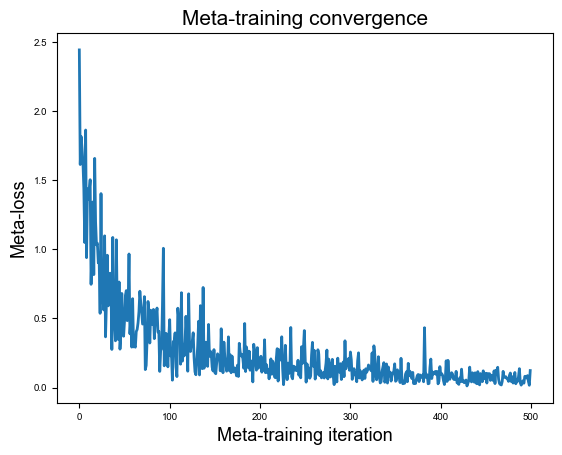

In [85]:
min_len = min(len(l) for l in all_meta_losses)
loss_mat = np.array([l[:min_len] for l in all_meta_losses], dtype=np.float64)

loss_mean, loss_sem = mean_sem_across_seeds(loss_mat)

plt.figure()
plt.plot(loss_mean)
plt.xlabel("Meta-training iteration")
plt.ylabel("Meta-loss")
plt.title("Meta-training convergence")
plt.show()


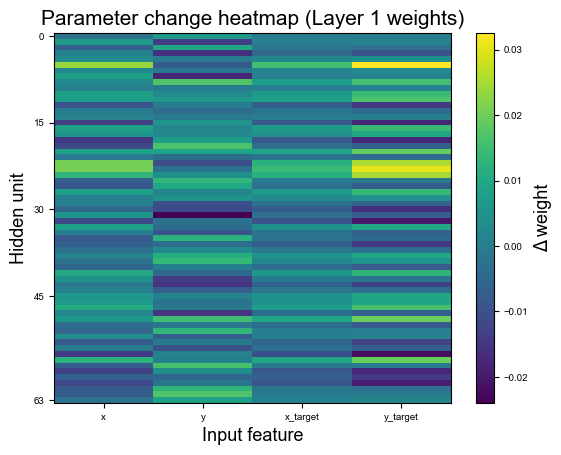

In [86]:
target_xy = sample_target(radius=1.5)
theta = sample_rotation(max_angle=0.4)

deltas = param_deltas(meta_pol, target_xy, k=10, theta=theta, gain=1.0, inner_lr=inner_lr, T=T, dt=dt)
W = deltas["net.0.weight"].numpy()

plt.figure()
plt.imshow(W, aspect="auto")
plt.colorbar(label="Δ weight")
plt.title("Parameter change heatmap (Layer 1 weights)")
plt.yticks([0, 15, 30, 45, 63])
plt.xticks([0, 1, 2, 3], ["x", "y", "x_target", "y_target"])
plt.xlabel("Input feature")
plt.ylabel("Hidden unit")
plt.show()
